In [1]:
#importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv('/content/drive/MyDrive/Movie prediction sucesss - Sai nikhita/movie_metadata.csv')
df.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


In [3]:
df.shape

(5043, 28)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   object 
 1   director_name              4939 non-null   object 
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   object 
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5036 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64

In [5]:
#Describing the numerical data - 16 columns
df.describe()

,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,gross,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
count,4993.000000,5028.000000,4939.000000,5020.000000,5036.000000,4.159000e+03,5.043000e+03,5043.000000,5030.000000,5022.000000,4.551000e+03,4935.000000,5030.000000,5043.000000,4714.000000,5043.000000
mean,140.194272,107.201074,686.509212,645.009761,6560.047061,4.846841e+07,8.366816e+04,9699.063851,1.371173,272.770808,3.975262e+07,2002.470517,1651.754473,6.442138,2.220403,7525.964505
std,121.601675,25.197441,2813.328607,1665.041728,15020.759120,6.845299e+07,1.384853e+05,18163.799124,2.013576,377.982886,2.061149e+08,12.474599,4042.438863,1.125116,1.385113,19320.445110
min,1.000000,7.000000,0.000000,0.000000,0.000000,1.620000e+02,5.000000e+00,0.000000,0.000000,1.000000,2.180000e+02,1916.000000,0.000000,1.600000,1.180000,0.000000
25%,50.000000,93.000000,7.000000,133.000000,614.000000,5.340988e+06,8.593500e+03,1411.000000,0.000000,65.000000,6.000000e+06,1999.000000,281.000000,5.800000,1.850000,0.000000
50%,110.000000,103.000000,49.000000,371.500000,988.000000,2.551750e+07,3.435900e+04,3090.000000,1.000000,156.000000,2.000000e+07,2005.000000,595.000000,6.600000,2.350000,166.000000
75%,195.000000,118.000000,194.500000,636.000000,11000.000000,6.230944e+07,9.630900e+04,13756.500000,2.000000,326.000000,4.500000e+07,2011.000000,918.000000,7.200000,2.350000,3000.000000
max,813.000000,511.000000,23000.000000,23000.000000,640000.000000,7.605058e+08,1.689764e+06,656730.000000,43.000000,5060.000000,1.221550e+10,2016.000000,137000.000000,9.500000,16.000000,349000.000000


In [6]:
 #Describing the categorical data - 12 columns
 df.describe(include='object')

,color,director_name,actor_2_name,genres,actor_1_name,movie_title,actor_3_name,plot_keywords,movie_imdb_link,language,country,content_rating
count,5024,4939,5030,5043,5036,5043,5020,4890,5043,5029,5038,4740
unique,2,2398,3032,914,2097,4917,3521,4760,4919,46,65,18
top,Color,Steven Spielberg,Morgan Freeman,Drama,Robert De Niro,Pan,Steve Coogan,based on novel,http://www.imdb.com/title/tt2224026/?ref_=fn_t...,English,USA,R
freq,4815,26,20,236,49,3,8,4,3,4704,3807,2118


In [7]:
#Categorising the target varible
bins = [ 1, 3, 6, 10] # # Define the bin edges
labels = ['FLOP', 'AVG', 'HIT'] # Define the category labels
df['imdb_binned'] = pd.cut(df['imdb_score'], bins=bins, labels=labels) # Apply binning

Text(0.5, 1.0, 'Categorization of Movies')

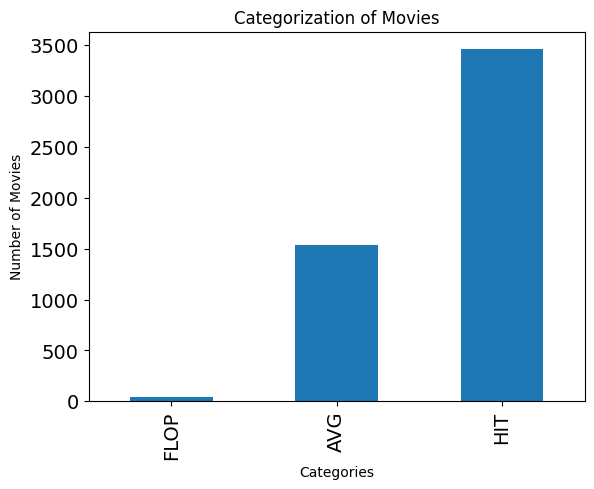

In [8]:
df.groupby(['imdb_binned'], observed=True).size().plot(kind="bar", fontsize=14)
plt.xlabel('Categories')
plt.ylabel('Number of Movies')
plt.title('Categorization of Movies')
# OR USE
# Count the number of occurrences of each category
# movies['imdb_binned'].value_counts().sort_index().plot(kind='bar', fontsize=14)
# plt.xlabel('Categories')
# plt.ylabel('Number of Movies')
# plt.title('Categorization of Movies')

In [9]:
df.head(5)

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,imdb_binned
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000,HIT
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0,HIT
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000,HIT
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000,HIT
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0,HIT


In [10]:
df.shape

(5043, 29)

In [11]:
#Total null values present in each column
df.isnull().sum()[df.isnull().sum() > 0] # counts missing values per column

,0
color,19
director_name,104
num_critic_for_reviews,50
duration,15
director_facebook_likes,104
actor_3_facebook_likes,23
actor_2_name,13
actor_1_facebook_likes,7
gross,884
actor_1_name,7


In [12]:
df.dropna(axis=0,subset=['color','director_name',
'num_critic_for_reviews',
'duration',
'director_facebook_likes',
'actor_3_facebook_likes',
'actor_2_name',
'actor_1_facebook_likes',
'actor_1_name',
'actor_3_name',
'facenumber_in_poster',
'plot_keywords',
'num_user_for_reviews',
'language',
'country',
'title_year',
'actor_2_facebook_likes'],inplace=True)


In [13]:
df.shape

(4727, 29)

In [14]:
# Checking how to fill the other missing values
df.isnull().sum()[df.isnull().sum() > 0] # counts missing values per column

,0
gross,636
content_rating,169
budget,351
aspect_ratio,205


In [15]:
df["color"].value_counts()

,count
color,
Color,4527
Black and White,200


In [16]:
df["content_rating"].value_counts()

,count
content_rating,
R,2075
PG-13,1433
PG,681
G,109
Not Rated,100
Unrated,58
Approved,55
X,13
Passed,9


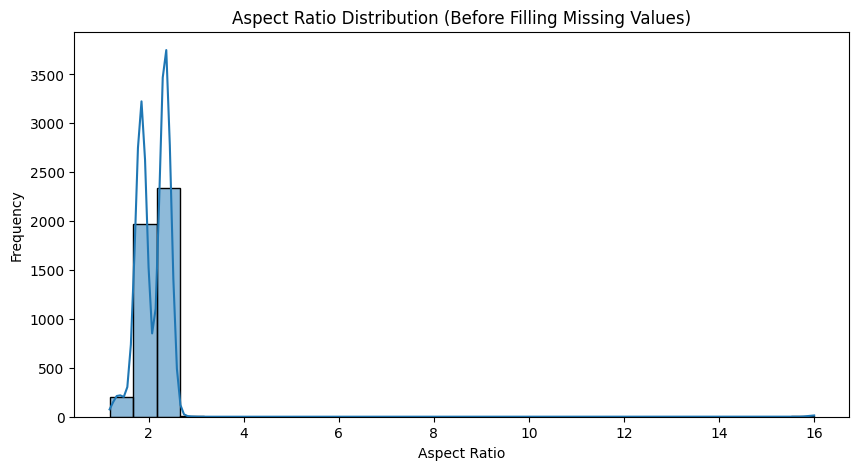

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(df['aspect_ratio'], kde=True, bins=30)
plt.title('Aspect Ratio Distribution (Before Filling Missing Values)')
plt.xlabel('Aspect Ratio')
plt.ylabel('Frequency')
plt.show()

In [18]:
# Repalce the color column with color as most of the movies is colored
df['color'] = df['color'].fillna("Color")
# Replace the content rating with Value R as it has highest frequency
df['content_rating'] = df['content_rating'].fillna("R")
# Replace the aspect_ratio with the median of the value
df["aspect_ratio"] = df["aspect_ratio"].fillna(df["aspect_ratio"].median())
# We need to replace the value in budget with the median of the value
df["budget"] = df["budget"].fillna(df["budget"].median())
# We need to replace the value in gross with the median of the value
df["gross"] = df["gross"].fillna(df["gross"].median())

# New DataFrame
duplicates = df.duplicated()
# See how many duplicated rows there are
print(duplicates.sum())

42


In [19]:
df = df.drop_duplicates()
df.shape

(4685, 29)

In [20]:
# Describing the categorical data after dropping missing values - 12 columns
df.describe(include='object')

,color,director_name,actor_2_name,genres,actor_1_name,movie_title,actor_3_name,plot_keywords,movie_imdb_link,language,country,content_rating
count,4685,4685,4685,4685,4685,4685,4685,4685,4685,4685,4685,4685
unique,2,2235,2810,875,1917,4606,3298,4602,4608,39,57,15
top,Color,Steven Spielberg,Morgan Freeman,Drama,Robert De Niro,King Kong,Steve Coogan,animal name in title|ape abducts a woman|goril...,http://www.imdb.com/title/tt0360717/?ref_=fn_t...,English,USA,R
freq,4487,26,20,209,48,3,8,3,3,4398,3561,2223


In [21]:
# Describing the numerical data after dropping the missing values - 16 columns
df.describe()

,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,gross,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
count,4685.000000,4685.000000,4685.000000,4685.00000,4685.000000,4.685000e+03,4.685000e+03,4685.000000,4685.000000,4685.000000,4.685000e+03,4685.000000,4685.000000,4685.000000,4685.000000,4685.000000
mean,146.200640,108.664674,712.499680,663.66318,6840.957311,4.586352e+07,8.809864e+04,10105.227535,1.358164,285.706937,3.942768e+07,2002.151974,1723.644824,6.432188,2.125748,7803.222412
std,121.010333,22.563603,2867.053757,1689.37736,15006.331505,6.389637e+07,1.409107e+05,18261.670472,2.009425,384.162398,2.030164e+08,12.332687,4143.557613,1.097831,0.639151,19642.070018
min,1.000000,14.000000,0.000000,0.00000,0.000000,1.620000e+02,5.000000e+00,0.000000,0.000000,1.000000,2.180000e+02,1927.000000,0.000000,1.600000,1.180000,0.000000
25%,57.000000,94.000000,8.000000,141.00000,638.000000,8.025872e+06,1.098600e+04,1509.000000,0.000000,75.000000,8.000000e+06,1999.000000,300.000000,5.800000,1.850000,0.000000
50%,117.000000,104.000000,52.000000,383.00000,1000.000000,2.604908e+07,3.827300e+04,3243.000000,1.000000,167.000000,2.000000e+07,2005.000000,617.000000,6.600000,2.350000,181.000000
75%,201.000000,118.000000,209.000000,642.00000,11000.000000,5.454052e+07,1.021290e+05,14504.000000,2.000000,341.000000,4.000000e+07,2010.000000,931.000000,7.200000,2.350000,5000.000000
max,813.000000,330.000000,23000.000000,23000.00000,640000.000000,7.605058e+08,1.689764e+06,656730.000000,43.000000,5060.000000,1.221550e+10,2016.000000,137000.000000,9.300000,16.000000,349000.000000


In [22]:
 #Dropping 2 columns
df.drop(columns=['movie_title','movie_imdb_link'],inplace=True)

In [23]:
 #Final shape of the data after Droping the 2 columns
df.shape

(4685, 27)

In [24]:
 #Label encoding the categorical columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cat_list=['color','director_name', 'actor_2_name',
        'genres', 'actor_1_name',
        'actor_3_name',
        'plot_keywords',
        'language', 'country', 'content_rating',
       'title_year','aspect_ratio']
df[cat_list]=df[cat_list].apply(lambda x:le.fit_transform(x))

In [25]:
#A sample of data after label encoding
df.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,imdb_binned
0,1,862,723.0,178.0,0.0,855.0,1300,1000.0,760505847.0,101,...,10,55,7,237000000.0,80,936.0,7.9,9,33000,HIT
1,1,741,302.0,169.0,563.0,1000.0,2046,40000.0,309404152.0,95,...,10,55,7,300000000.0,78,5000.0,7.1,14,0,HIT
2,1,1886,602.0,148.0,0.0,161.0,2301,11000.0,200074175.0,121,...,10,54,7,245000000.0,86,393.0,6.8,14,85000,HIT
3,1,352,813.0,164.0,22000.0,23000.0,486,27000.0,448130642.0,278,...,10,55,7,250000000.0,83,23000.0,8.5,14,164000,HIT
5,1,94,462.0,132.0,475.0,530.0,2355,640.0,73058679.0,119,...,10,55,7,263700000.0,83,632.0,6.6,14,24000,HIT


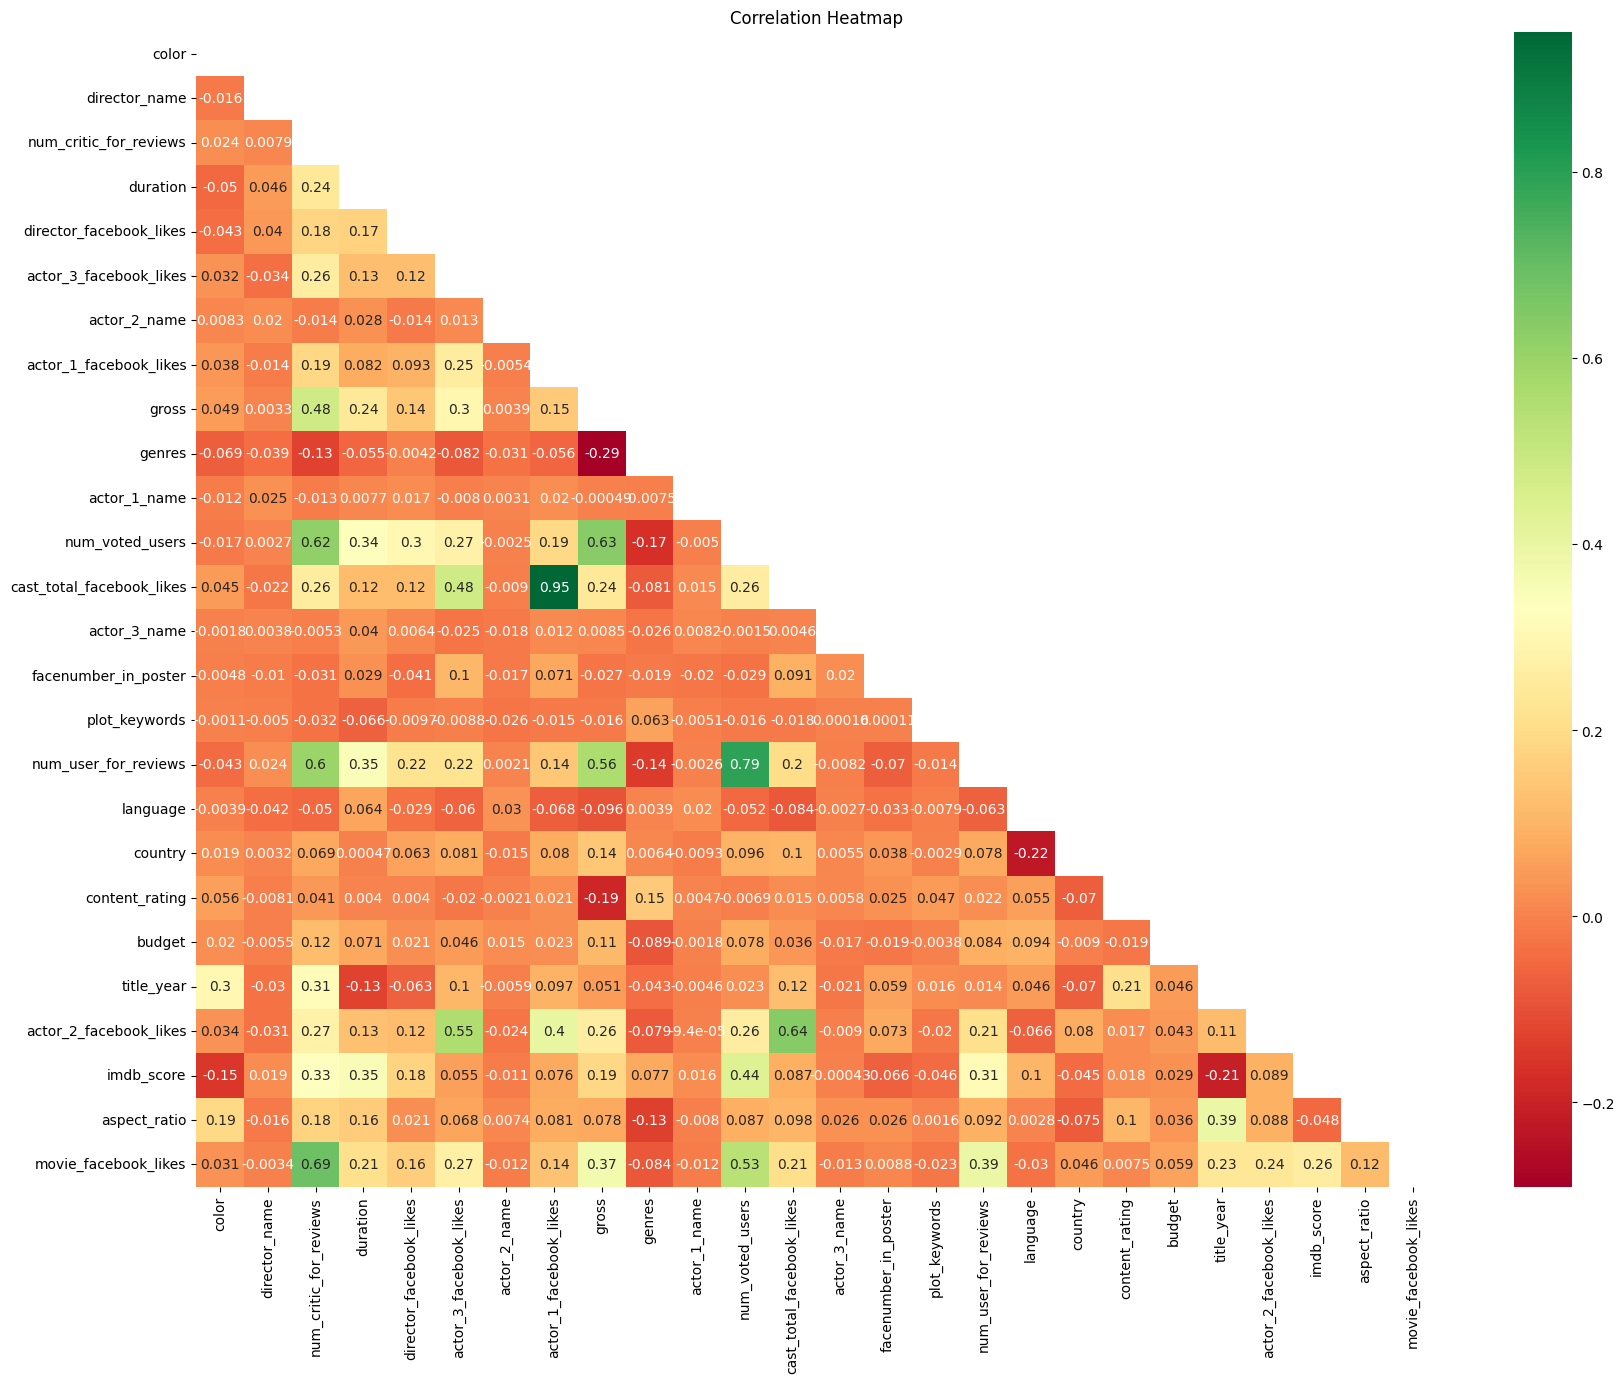

In [26]:
# Filter only numeric columns
numeric_movies = df.select_dtypes(include=['number'])

# Compute correlation matrix
corr = numeric_movies.corr()

# Create mask for upper triangle
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Plot heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns,
cmap='RdYlGn', annot=True, mask=mask)
plt.title('Correlation Heatmap')
plt.show()

In [27]:
#Removing few columns due to multicollinearity
df.drop(columns=['cast_total_facebook_likes','num_critic_for_reviews'],inplace=True)

In [28]:
#Removing the column "imdb_score" since we have "imdb_binned"
df.drop(columns=['imdb_score'],inplace=True)

In [29]:
df.shape

(4685, 24)

In [30]:
# STEP1: PREPARE VARIABLES
# Independent Variables
X = df.drop('imdb_binned', axis=1)
y = df['imdb_binned']
y

,imdb_binned
0,HIT
1,HIT
2,HIT
3,HIT
5,HIT
...,...
5034,HIT
5035,HIT
5037,HIT
5038,HIT


In [31]:
# STEP2: SPLIT DATA INTO TRAINING DATA AND TESTING DATA WHICH IS RANDOM SPLIT.
# TRAINING SIZE OR TESTING SIZE CAN BE SPECIFIED
# Tip: Press TAB
# Sequence of train and test is important else error
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0,stratify = y)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(3279, 23)
(3279,)
(1406, 23)
(1406,)


In [32]:
## Scaling the independent variables
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [33]:
#Training the Random Forest Classifier on Train data
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators = 100, criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)


RandomForestClassifier(criterion='entropy', random_state=0)

In [34]:
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[213   0 217]
 [  8   0   4]
 [ 72   0 892]]


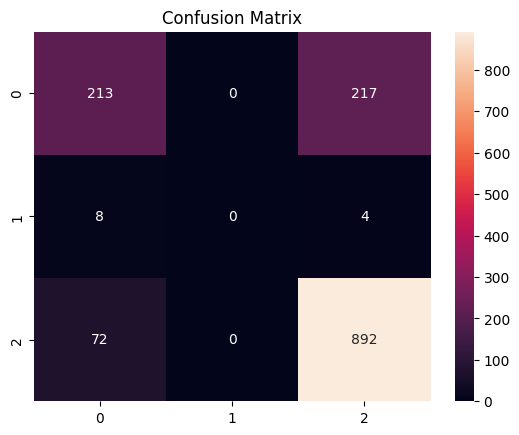

In [35]:
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [36]:
 #Classification Report
from sklearn.metrics import classification_report
# Set zero_division=0 to avoid warning when no predicted samples exist for a label
cr = classification_report(y_test, y_pred, zero_division=0)
print(cr)

              precision    recall  f1-score   support

         AVG       0.73      0.50      0.59       430
        FLOP       0.00      0.00      0.00        12
         HIT       0.80      0.93      0.86       964

    accuracy                           0.79      1406
   macro avg       0.51      0.47      0.48      1406
weighted avg       0.77      0.79      0.77      1406



In [37]:
importances = classifier.feature_importances_
features = df.iloc[:, 0:23].columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

                    Feature  Importance
10          num_voted_users    0.112236
2                  duration    0.086622
7                     gross    0.062464
8                    genres    0.062096
14     num_user_for_reviews    0.058309
18                   budget    0.054771
19               title_year    0.054368
4    actor_3_facebook_likes    0.051408
22     movie_facebook_likes    0.050855
3   director_facebook_likes    0.047795


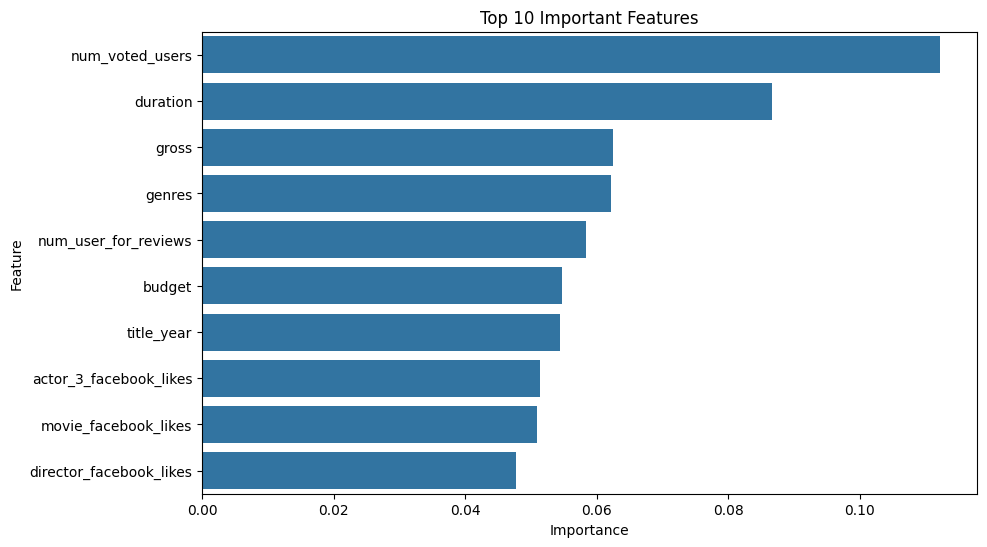

In [38]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title("Top 10 Important Features")
plt.show()

In [39]:
# Creeating another dataframe to be used in PowerBI Vizualization
movies_powerbi=pd.read_csv('/content/drive/MyDrive/Movie prediction sucesss - Sai nikhita/movie_metadata.csv')

In [40]:
movies_powerbi.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


In [41]:
movies_powerbi.to_csv('/content/drive/MyDrive/Movie prediction sucesss - Sai nikhita/movie prediction success.pbix')

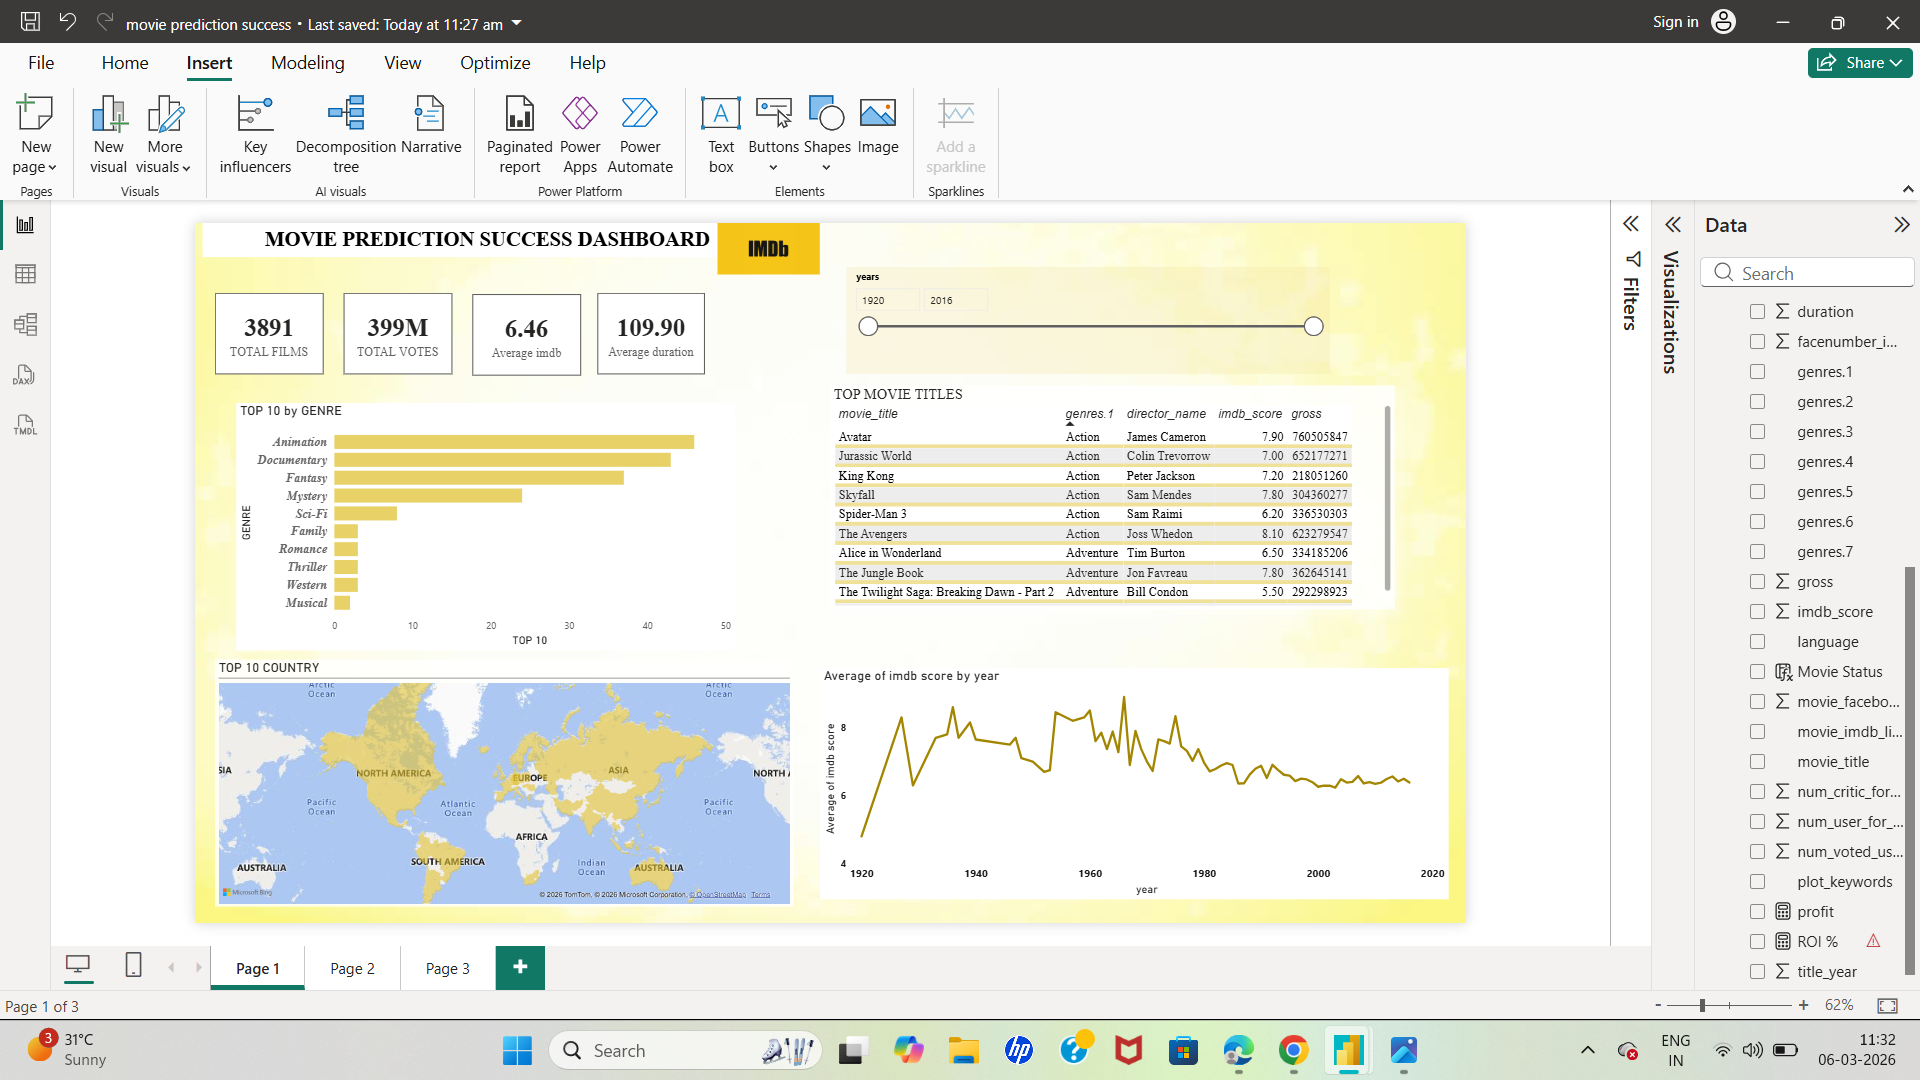